In [228]:

# библиотеки
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import scipy.stats as sts
from itertools import combinations
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [229]:
# load data
%store -r data top_genres top_themes
pd.set_option('display.float_format', '{:.3f}'.format)
data = data.sample(n=50,random_state=1)
top_genres = top_genres['Genre'].unique()
print(len(data))

50


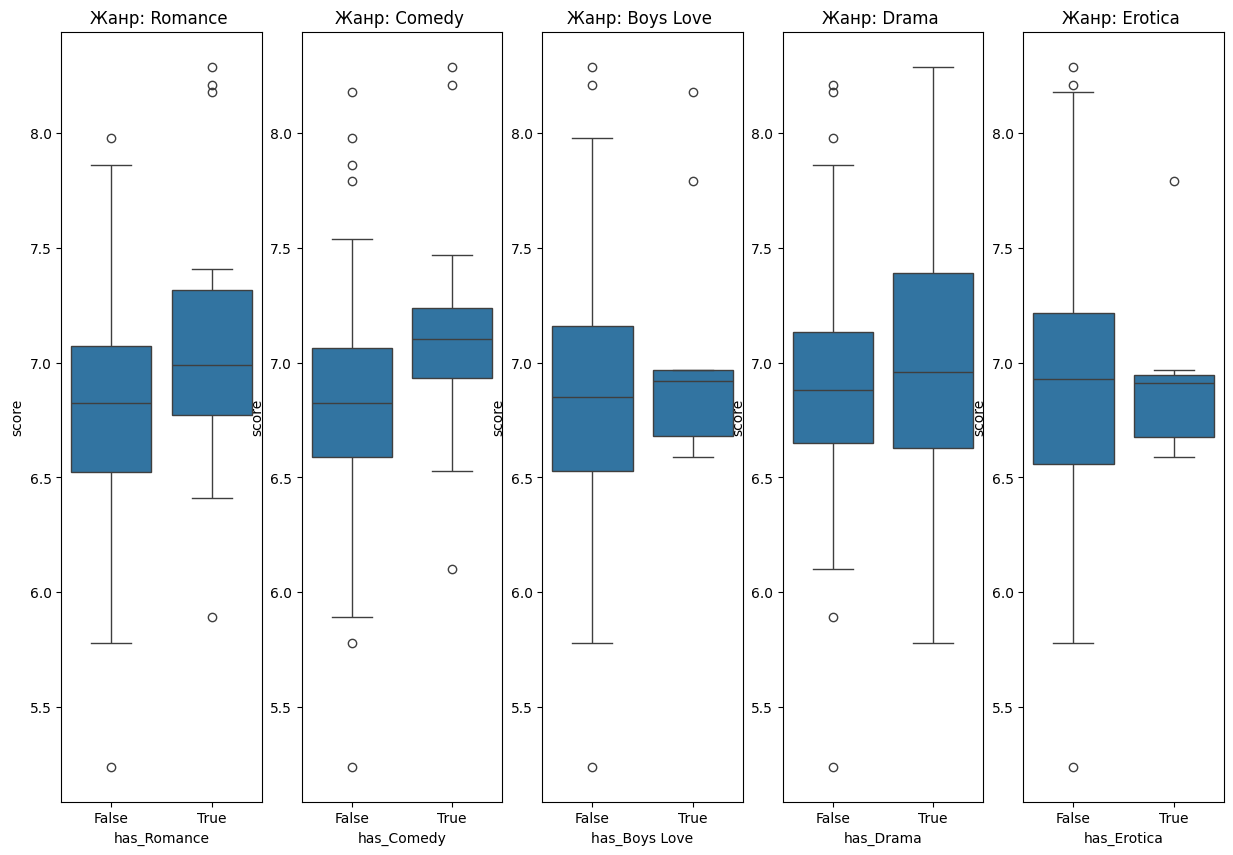

In [230]:
fig, axes = plt.subplots(1, len(top_genres),figsize=(15, 10))  # 1 строкa, 5 столбцов
for i, genre in enumerate(top_genres):
    data[f'has_{genre}'] = data['genres'].apply(lambda x: genre in x)
    sns.boxplot(x=f'has_{genre}', y='score', data=data, ax=axes[i])
    axes[i].set_title(f'Жанр: {genre} ')

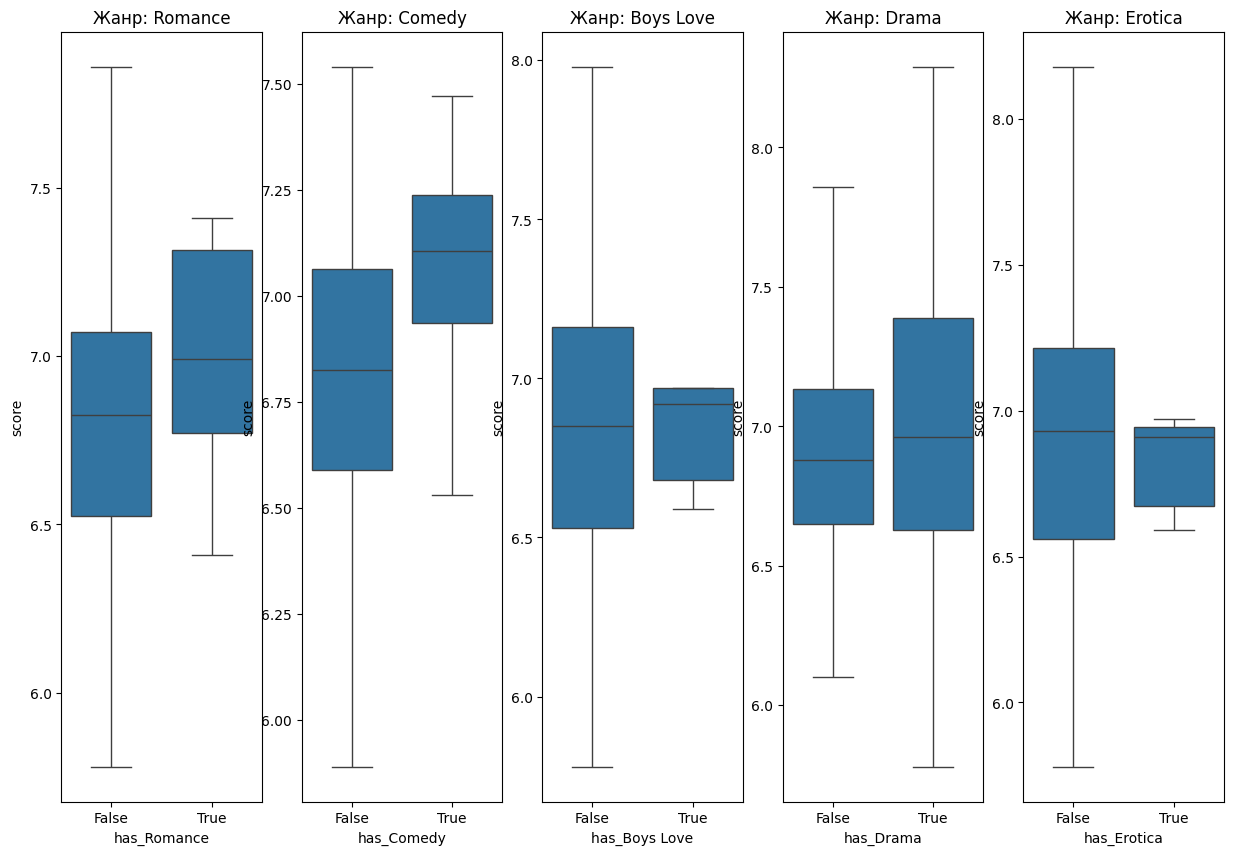

In [231]:
fig, axes = plt.subplots(1, len(top_genres),figsize=(15, 10))  # 1 строкa, 5 столбцов
for i, genre in enumerate(top_genres):
    sns.boxplot(x=f'has_{genre}', y='score', data=data, ax=axes[i],showfliers=False)
    axes[i].set_title(f'Жанр: {genre}')

In [232]:
filter_data_genre = {}
for genre in top_genres:
    data[f'is_{genre}'] = data['genres'].apply(lambda x: 1 if genre in x else 0)
    genre_yes = data[data[f'is_{genre}'] == 1]['score']
    genre_no = data[data[f'is_{genre}'] == 0]['score']
    _, pl = sts.levene(genre_yes, genre_no)
    _,pny = sts.shapiro(genre_yes)
    _,pnn = sts.shapiro(genre_no)
    filter_data_genre[genre] = [round(pl,3),round(pnn,3),round(pny,3)]
    print(f'{genre}:\nТест Левена: {pl:.3f}\np-value(да):{pny:.3f}\np-value(нет):{pnn:.3f}\n')


Romance:
Тест Левена: 0.731
p-value(да):0.194
p-value(нет):0.226

Comedy:
Тест Левена: 0.978
p-value(да):0.199
p-value(нет):0.164

Boys Love:
Тест Левена: 0.471
p-value(да):0.012
p-value(нет):0.498

Drama:
Тест Левена: 0.678
p-value(да):0.998
p-value(нет):0.091

Erotica:
Тест Левена: 0.218
p-value(да):0.021
p-value(нет):0.314



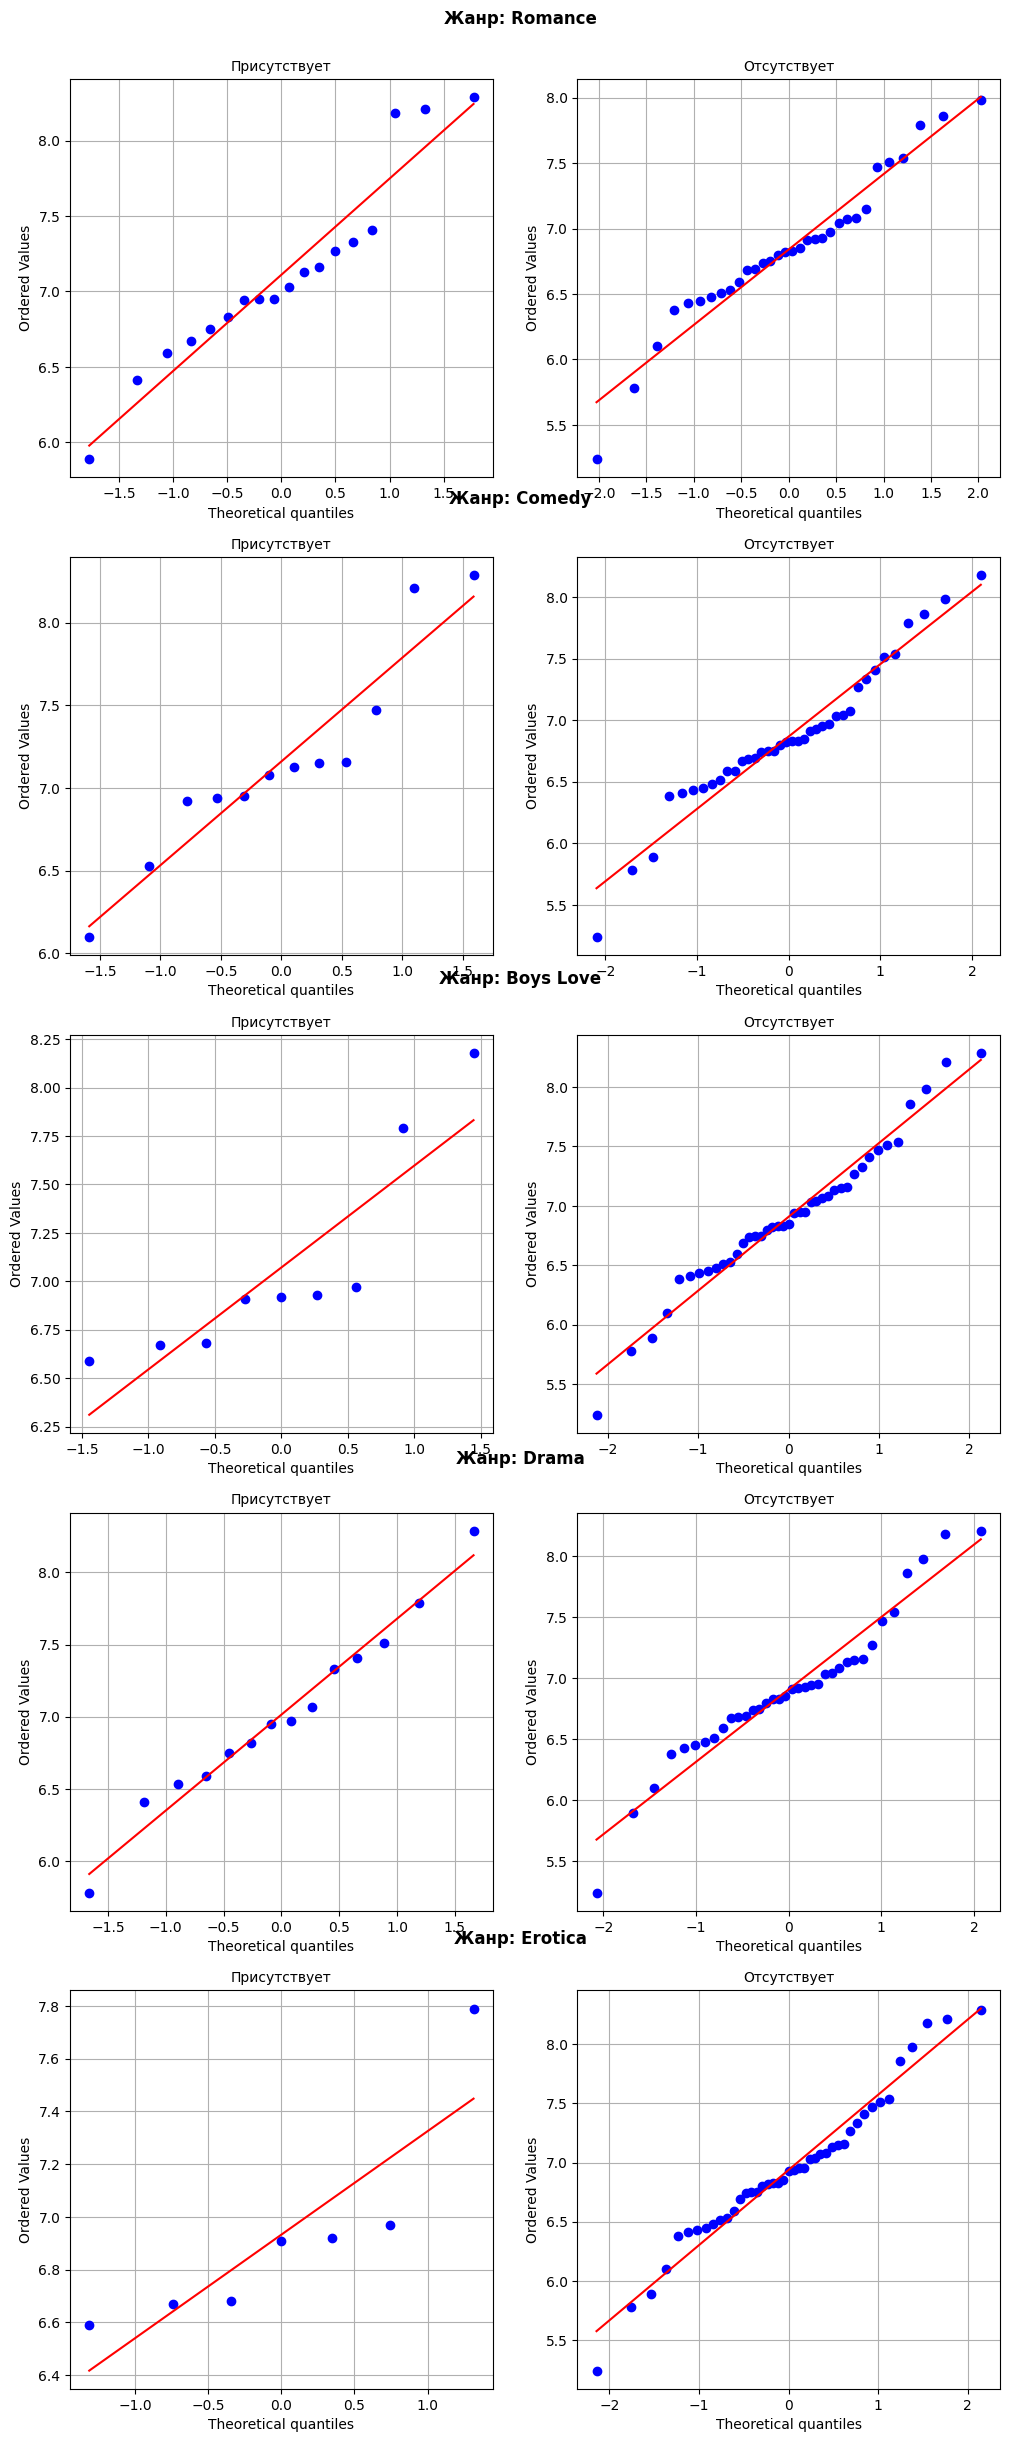

In [233]:
fig, axes = plt.subplots(len(top_genres), 2,figsize=(12, 6*len(top_genres))) 
for i in range(len(top_genres)):
    genre = top_genres[i]

    genre_yes = data[data[f'is_{genre}'] == 1]['score'].dropna()
    genre_no = data[data[f'is_{genre}'] == 0]['score'].dropna()

    sts.probplot(genre_yes, plot=axes[i, 0])  # Используем plot вместо ax
    sts.probplot(genre_no, plot=axes[i, 1])   # И индексацию [i,0] вместо [i][0]
    
    fig.text(
        x=0.5,  # Центрируем по горизонтали
        y=0.9 - i*0.8/len(top_genres),  # Позиционируем по вертикали
        s=f'Жанр: {genre}',
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold'
    )
    
    # Подписи для подграфиков (опционально)
    axes[i, 0].set_title('Присутствует', fontsize=10)
    axes[i, 1].set_title('Отсутствует', fontsize=10)
    axes[i, 0].grid(True)
    axes[i, 1].grid(True)

In [234]:
for genre in top_genres:
    arr = filter_data_genre[genre]
    if arr[0] > 0.005 and arr[1] > 0.05 and arr[2] > 0.05:

        genre_yes = data[data[f'is_{genre}'] == 1]['score'].dropna()
        genre_no = data[data[f'is_{genre}'] == 0]['score'].dropna()

        f_stat, p_value = sts.f_oneway(genre_yes, genre_no)
        f_critical = sts.f.ppf(0.95, 1, 48)
        
        formula = f'score ~ C(is_{genre})'
        model = ols(formula, data=data).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        

        sum_sq_0 = anova_table['sum_sq'][f'C(is_{genre})'] 
        sum_sq_1 = anova_table['sum_sq'][f'Residual']
        R2 = sum_sq_0/(sum_sq_0 + sum_sq_1)
        
        print(f'{genre}:\n F-статистика:{f_stat:.3f}\n F-крит:{f_critical:.3f}\n P-value:{p_value:.3f}\n')
        print(f'R^2 = {R2:.3f}',end="\n\n")
        print(anova_table.round(3),end="\n\n")


Romance:
 F-статистика:2.423
 F-крит:4.043
 P-value:0.126

R^2 = 0.048

               sum_sq     df     F  PR(>F)
C(is_Romance)   0.845  1.000 2.423   0.126
Residual       16.741 48.000   NaN     NaN

Comedy:
 F-статистика:2.257
 F-крит:4.043
 P-value:0.140

R^2 = 0.045

              sum_sq     df     F  PR(>F)
C(is_Comedy)   0.790  1.000 2.257   0.140
Residual      16.796 48.000   NaN     NaN

Drama:
 F-статистика:0.317
 F-крит:4.043
 P-value:0.576

R^2 = 0.007

             sum_sq     df     F  PR(>F)
C(is_Drama)   0.116  1.000 0.317   0.576
Residual     17.470 48.000   NaN     NaN

